In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':14})
import matplotlib.colors as colors
import matplotlib.colors as mcolors
from matplotlib.cm import GnBu, viridis

import sys
sys.path.insert(0, '/projects/b1094/jding/athena/vis/python')
import athena_read
import glob


In [64]:
## Snapshots registration
sim_name = 'disk-2d-planet1a'
path = '/scratch/phn2956/' + sim_name + '/'
#path = '/scratch/phn2956/disk_2d_viscous_gap/'
snapshot_list = sorted(glob.glob(path+'disk.out1.*.athdf'))


# Results over whole sim

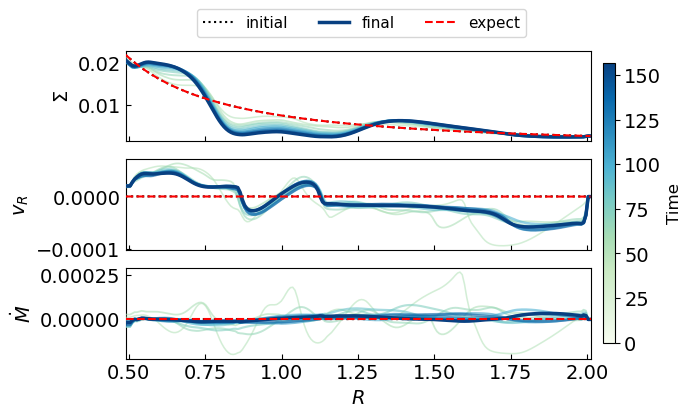

In [65]:
## Plot density, v_r, and Mdot

snapshot_plot = snapshot_list[0:11:1]

## NOTE: I think the color scaling is wrong when the first snapshot isn't i=0, but it's a minor point
norm   = mcolors.PowerNorm(gamma=1.5, vmin=0, vmax=len(snapshot_plot)-1)
colors = [GnBu(0.3 + 0.7 * norm(i)) for i in range(len(snapshot_plot))]

fig,axs = plt.subplots(3,1, figsize=(6,4),sharex=True,sharey=False)

for i, frame in enumerate(snapshot_plot):
    
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho", "vel1", "vel2", "vel3"])
    t_sim = ath_data['Time']
    #print('loading snapshot at t= %5.1f'%t_sim)
    
    #### Read Athena++ data: coordinates. ####
    rad_app = ath_data['x1v']
    phi_app = ath_data['x2v']
    zzz_app = ath_data['x3v']
    d_rad = ath_data['x1f'][1]-ath_data['x1f'][0]
    d_phi = ath_data['x2f'][1]-ath_data['x2f'][0]
    
    rad_3d, phi_3d, zzz_3d = np.meshgrid(rad_app, phi_app, zzz_app, indexing='ij')
    
    #### Read Athena++ data: velosity field. ####    
    vx1 = np.swapaxes(ath_data['vel1'],0,2)
    vx2 = np.swapaxes(ath_data['vel2'],0,2)
    vx3 = np.swapaxes(ath_data['vel3'],0,2)
    den = np.swapaxes(ath_data['rho'],0,2)

    Sigma_integrand = den*rad_3d*d_rad*d_phi
    Sigma = np.sum(Sigma_integrand[:,2:-2,0],axis=1)/(2*np.pi*rad_app)

    vr_integrand = vx1*rad_3d*d_rad*d_phi
    vr = np.sum(vr_integrand[:,2:-2,0],axis=1)/(2*np.pi*rad_app)
    
    Mdot_integrand = den*vx1*rad_3d*d_rad*d_phi
    Mdot = np.sum(Mdot_integrand[:,2:-2,0],axis=1)#/(2*np.pi*rad_app)
    
    #### Plot
    
    current_color = colors[i]
    lw     = 1.0 + 1.5 * (i / len(snapshot_plot))
    zorder = i + 10 
    
    if t_sim== 0:
        kws = {'c': 'k', 'ls':':','lw': 1.5, 'label': r'initial' % t_sim, 'zorder': zorder}
    elif i == len(snapshot_plot) - 1:
        kws = {'c': '#084081', 'lw': 2.5, 'label': r'final' % t_sim, 'zorder': zorder + 100}
    else:
        kws = {'c': current_color, 'lw': lw, 'alpha': 0.6, 'zorder': zorder}
        
    axs[0].plot(rad_app,Sigma,**kws)
    axs[1].plot(rad_app,vr,**kws)
    axs[2].plot(rad_app,Mdot,**kws)
     
sm = plt.cm.ScalarMappable(cmap=GnBu, norm=plt.Normalize(vmin=0, vmax=t_sim))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [from left, from bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Time', fontsize=12)

#### Add analytical solutions
Sigma_sol = Sigma[-1] * (rad_app/rad_app[-1])**-1.5
vR_sol    = vr[-1] * (rad_app/rad_app[-1])**0.5
Mdot_sol  = Mdot[-1] * (rad_app/rad_app[-1])**0

kws_theory = {'c': 'r', 'lw': 1.5, 'ls': '--', 'zorder': zorder+200}
axs[0].plot(rad_app,Sigma_sol,**kws_theory)
axs[1].plot(rad_app,vR_sol,**kws_theory)
axs[2].plot(rad_app,Mdot_sol,**kws_theory)
axs[0].plot([],[],c='r',lw=1.5,ls='--',zorder=zorder+200,label='expect')

#### labels
axs[0].set_ylabel(r'$\Sigma$')
axs[1].set_ylabel(r'$v_{R}$')
axs[2].set_ylabel(r'$\dot{M}$')
axs[-1].set_xlabel(r'$R$')
axs[-1].set_xlim(rad_app[[0, -1]])

axs[0].legend(
    fontsize=11,
    loc='upper left',        
    bbox_to_anchor=(0.15, 1.02, 0.9, .452), 
    ncol=3,                  
    #mode="expand",          
    borderaxespad=0.1       
)


for ax in axs.flatten():
    ax.tick_params(which='both',direction='in')

save_fig = False
if save_fig:
    plt.savefig("Figs/Snapshots/" + sim_name + "-snapshots.png", bbox_inches='tight')


## print slopes of profiles

In [ ]:
# indices of the two points we use to find the slope
i1 = 10
i2 = 35

slope = (np.log(Sigma[i2]) - np.log(Sigma[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("Sigma slope=", np.round(slope,3))

vr_abs = np.abs(vr)
slope = (np.log(vr_abs[i2]) - np.log(vr_abs[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("vr slope=", np.round(slope,3))

Mdot_abs = np.abs(Mdot)
slope = (np.log(Mdot_abs[i2]) - np.log(Mdot_abs[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("Mdot slope=", np.round(slope,3))

# $\rho(\vec{r})$ animation

In [ ]:
phi_3d.shape

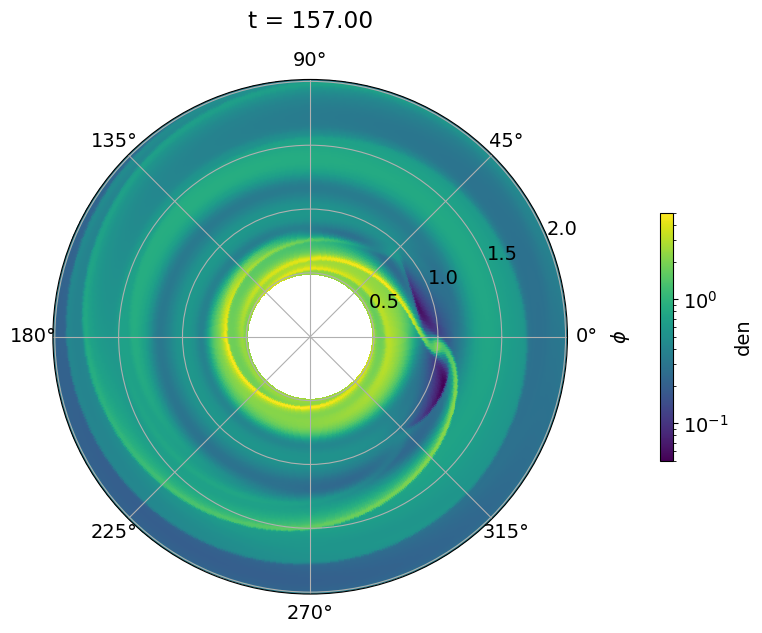

In [68]:
# TODO: plot density in xy-plane

ind = 10

snapshot_plot = snapshot_list[10:11:1] # snapshot_list[0:101:5]

for i, frame in enumerate(snapshot_plot):
    
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho"])
    t_sim = ath_data['Time']
    #print('loading snapshot at t= %5.1f'%t_sim)
    
    #### Read Athena++ data: coordinates. ####
    rad_app = ath_data['x1v']
    phi_app = ath_data['x2v'][2:-2] # ignore ghost zones
    d_rad = ath_data['x1f'][1]-ath_data['x1f'][0]
    d_phi = ath_data['x2f'][1]-ath_data['x2f'][0]
    
    rad_3d, phi_3d = np.meshgrid(rad_app, phi_app, indexing='ij')
    
    #### Read Athena++ data: density values. ####    
    den = np.swapaxes(ath_data['rho'],0,2)

    fig = plt.figure(figsize=(8,7))
    #ax = fig.add_subplot()
    ax = fig.add_subplot(projection='polar')
    
    ## view from above
    kws = {'cmap': 'viridis', 'norm': mcolors.LogNorm(vmin=5e-2, vmax=5e0)}
    c = ax.pcolormesh(phi_3d[:, :], rad_3d[:, :], den[:,2:-2,0], **kws)

    #cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(c, ax=ax, label="den", pad=.15, fraction=0.02)
    
    ## set axes
    # ax.set_rlim(.2, 2.2)
    #ax.xaxis.set_label_position('top') 
    #ax.set_xlabel("r", labelpad=-370)
    
    #ax.set_thetalim(np.pi/2- .3, np.pi/2 + .3)
    #ax.set_theta_offset(np.pi/2)
    #ax.set_theta_direction(-1)
    ax.set_ylabel(r"$\phi$", labelpad=30)
    ax.yaxis.set_label_position("right")
    ax.set_yticks([0.5, 1, 1.5, 2]) # ticks in radial direction
    #ax.yaxis.tick_right()
    
    plt.title("t = {t_sim:.2f}".format(t_sim=t_sim), y=1.1, pad=0.05)
    
    save_fig = False
    if save_fig:
        plt.savefig("Figs/" + sim_name + "-rhos/" + "%05d"%i + ".png")

    #plt.close()
    
plt.show()